# Step 1: Download libraries and data

In [359]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree


In [360]:
# Loading the dataset
df = pd.read_csv('C:/Users/sanad/Downloads/US-pumpkins.csv')


# Step 2: Exploratory Data Analysis (EDA)

In [361]:
# Show the first 5 rows
print(df.head())

   City Name Type       Package      Variety Sub Variety  Grade     Date  \
0  BALTIMORE  NaN  24 inch bins          NaN         NaN    NaN  4/29/17   
1  BALTIMORE  NaN  24 inch bins          NaN         NaN    NaN   5/6/17   
2  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   

   Low Price  High Price  Mostly Low  ...  Unit of Sale Quality Condition  \
0      270.0       280.0       270.0  ...           NaN     NaN       NaN   
1      270.0       280.0       270.0  ...           NaN     NaN       NaN   
2      160.0       160.0       160.0  ...           NaN     NaN       NaN   
3      160.0       160.0       160.0  ...           NaN     NaN       NaN   
4       90.0       100.0        90.0  ...           NaN     NaN       NaN   

  Appearance Storage  Crop Repack  Trans Mode  Unnamed: 24  Unnamed: 25  
0     

In [362]:
# Check data types of each column
print(df.dtypes)

City Name           object
Type                object
Package             object
Variety             object
Sub Variety         object
Grade              float64
Date                object
Low Price          float64
High Price         float64
Mostly Low         float64
Mostly High        float64
Origin              object
Origin District     object
Item Size           object
Color               object
Environment        float64
Unit of Sale        object
Quality            float64
Condition          float64
Appearance         float64
Storage            float64
Crop               float64
Repack              object
Trans Mode         float64
Unnamed: 24        float64
Unnamed: 25         object
dtype: object


In [363]:
# Statistical summary of numeric columns
print(df.describe())


       Grade    Low Price   High Price   Mostly Low  Mostly High  Environment  \
count    0.0  1757.000000  1757.000000  1654.000000  1654.000000          0.0   
mean     NaN   124.571338   132.970939   128.170550   132.491802          NaN   
std      NaN    83.876591    89.524958    86.512161    88.442967          NaN   
min      NaN     0.240000     0.240000     0.240000     0.240000          NaN   
25%      NaN    24.000000    24.500000    24.625000    26.125000          NaN   
50%      NaN   140.000000   150.000000   147.000000   150.000000          NaN   
75%      NaN   180.000000   200.000000   185.000000   200.000000          NaN   
max      NaN   480.000000   480.000000   480.000000   480.000000          NaN   

       Quality  Condition  Appearance  Storage  Crop  Trans Mode  Unnamed: 24  
count      0.0        0.0         0.0      0.0   0.0         0.0          0.0  
mean       NaN        NaN         NaN      NaN   NaN         NaN          NaN  
std        NaN        NaN     

In [364]:
# Identify columns with missing values
print(df.isnull().sum())

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64


# Step 3: Data cleaning (pre-processing)

In [365]:
# 1. Removing entirely empty columns to simplify the dataset
df_cleaned = df.dropna(axis=1, how='all')

In [366]:
print("--- Columns Remaining (Only empty ones removed) ---")
print(df_cleaned.columns.tolist())

--- Columns Remaining (Only empty ones removed) ---
['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High', 'Origin', 'Origin District', 'Item Size', 'Color', 'Unit of Sale', 'Repack', 'Unnamed: 25']


In [367]:
print("--- Data Shape ---")
print(df_cleaned.shape)

--- Data Shape ---
(1757, 17)


In [368]:
print("--- First 5 Rows ---")
print(df_cleaned.head())

--- First 5 Rows ---
   City Name Type       Package      Variety Sub Variety     Date  Low Price  \
0  BALTIMORE  NaN  24 inch bins          NaN         NaN  4/29/17      270.0   
1  BALTIMORE  NaN  24 inch bins          NaN         NaN   5/6/17      270.0   
2  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  9/24/16      160.0   
3  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  9/24/16      160.0   
4  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  11/5/16       90.0   

   High Price  Mostly Low  Mostly High    Origin Origin District Item Size  \
0       280.0       270.0        280.0  MARYLAND             NaN       lge   
1       280.0       270.0        280.0  MARYLAND             NaN       lge   
2       160.0       160.0        160.0  DELAWARE             NaN       med   
3       160.0       160.0        160.0  VIRGINIA             NaN       med   
4       100.0        90.0        100.0  MARYLAND             NaN       lge   

    Color Unit of Sale Repack

In [369]:
# 2. Identifying Categorical and Numerical features for separate processing
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns




In [370]:
# Handling Missing Values (Imputation Strategy)
# Categorical: Filling missing entries with 'Unknown'
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')
# Numerical: Filling missing entries with the Median to avoid outliers impact
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\2559934821.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = df_cleaned[col].fillna('Unknown')
C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\2559934821.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())


In [371]:
# Target Engineering: Calculating 'Average Price' as the basis for classification
df_cleaned['Average_Price'] = (df_cleaned['Low Price'] + df_cleaned['High Price']) / 2

C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\218663631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Average_Price'] = (df_cleaned['Low Price'] + df_cleaned['High Price']) / 2


In [372]:
# 5. Verify that the missing values ​​have completely disappeared
print("--- Missing Values After Imputation ---")
print(df_cleaned.isnull().sum())



--- Missing Values After Imputation ---
City Name          0
Type               0
Package            0
Variety            0
Sub Variety        0
Date               0
Low Price          0
High Price         0
Mostly Low         0
Mostly High        0
Origin             0
Origin District    0
Item Size          0
Color              0
Unit of Sale       0
Repack             0
Unnamed: 25        0
Average_Price      0
dtype: int64


In [373]:
print("--- Data Sample After Imputation ---")
print(df_cleaned.head())

--- Data Sample After Imputation ---
   City Name     Type       Package      Variety Sub Variety     Date  \
0  BALTIMORE  Unknown  24 inch bins      Unknown     Unknown  4/29/17   
1  BALTIMORE  Unknown  24 inch bins      Unknown     Unknown   5/6/17   
2  BALTIMORE  Unknown  24 inch bins  HOWDEN TYPE     Unknown  9/24/16   
3  BALTIMORE  Unknown  24 inch bins  HOWDEN TYPE     Unknown  9/24/16   
4  BALTIMORE  Unknown  24 inch bins  HOWDEN TYPE     Unknown  11/5/16   

   Low Price  High Price  Mostly Low  Mostly High    Origin Origin District  \
0      270.0       280.0       270.0        280.0  MARYLAND         Unknown   
1      270.0       280.0       270.0        280.0  MARYLAND         Unknown   
2      160.0       160.0       160.0        160.0  DELAWARE         Unknown   
3      160.0       160.0       160.0        160.0  VIRGINIA         Unknown   
4       90.0       100.0        90.0        100.0  MARYLAND         Unknown   

  Item Size    Color Unit of Sale Repack Unnamed:

# Step 4: Feature Engineering and Coding

In [374]:
# 1. Discretization: Converting the continuous 'Average Price' into 3 categorical bins (Low, Medium, High)
# Using qcut ensures an equal distribution of samples across the categories
df_cleaned['Price_Range'] = pd.qcut(df_cleaned['Average_Price'], q=3, labels=['Low', 'Medium', 'High'])

C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\3640692507.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Price_Range'] = pd.qcut(df_cleaned['Average_Price'], q=3, labels=['Low', 'Medium', 'High'])


In [375]:
# 2. Categorical Encoding: Converting text labels into numerical values for the ML model
le = LabelEncoder()
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\2070415752.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\2070415752.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
C:\Users\sanad\AppData\Local\Temp\ipykernel_17732\2070415752.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

In [376]:
# 3. Defining Feature Matrix (X) and Target Vector (y)
# We drop price-related columns to prevent "Data Leakage" (model predicting price using price)
X = df_cleaned.drop(['Average_Price', 'Price_Range', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High'], axis=1)
y = df_cleaned['Price_Range'] # Encode Target (Low/Medium/High) to 0/1/2

In [377]:
# Converting y to numbers also makes calculations easier later.
y = le.fit_transform(y)

print("--- Features (X) Sample ---")
print(X.head())
print("\n--- Target (y) Unique Values ---")
print(np.unique(y))

--- Features (X) Sample ---
   City Name  Type  Package  Variety  Sub Variety  Date  Origin  \
0          1     1        5       10            2    27       8   
1          1     1        5       10            2    32       8   
2          1     1        5        4            2    49       4   
3          1     1        5        4            2    49      23   
4          1     1        5        4            2    13       8   

   Origin District  Item Size  Color  Unit of Sale  Repack  Unnamed: 25  
0                4          3      2             4       0            4  
1                4          3      2             4       0            4  
2                4          4      0             4       1            4  
3                4          4      0             4       1            4  
4                4          3      0             4       1            4  

--- Target (y) Unique Values ---
[0 1 2]


# Step 5: Model training and evaluation

In [378]:
# Split data: 80% for training the model and 20% for testing its performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [379]:
# Initializing and Fitting the Decision Tree Classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [380]:
print("--- Training Completed! ---")
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")

--- Training Completed! ---
X_train size: (1405, 13)
X_test size: (352, 13)


In [381]:
# Making predictions on the unseen test set
y_pred = model.predict(X_test)
# Metrics: Calculating overall accuracy and detailed classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Accuracy: {accuracy:.2f} ---")

print("\n--- Classification Report ---")
target_names = ['High', 'Low', 'Medium'] 
print(classification_report(y_test, y_pred, target_names=target_names))

--- Model Accuracy: 0.97 ---

--- Classification Report ---
              precision    recall  f1-score   support

        High       0.94      0.97      0.96       110
         Low       0.99      1.00      1.00       111
      Medium       0.98      0.94      0.96       131

    accuracy                           0.97       352
   macro avg       0.97      0.97      0.97       352
weighted avg       0.97      0.97      0.97       352



# Step 6: Optimization and Visualization (pruning)

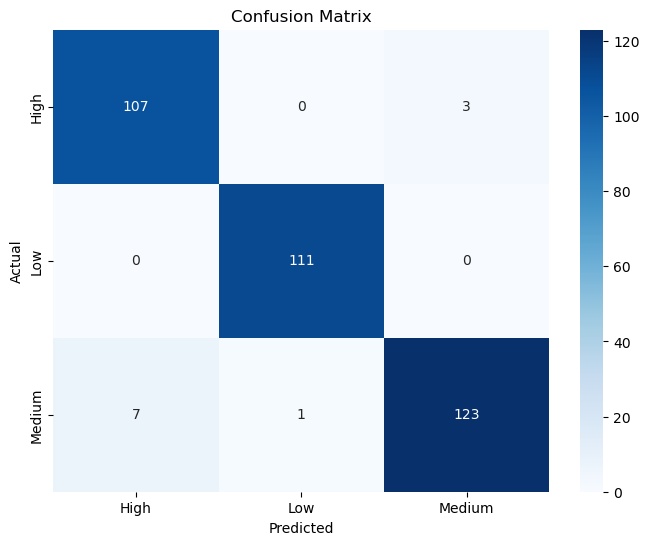

In [382]:
# 1. Confusion Matrix Visualization: To see where the model is making errors
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

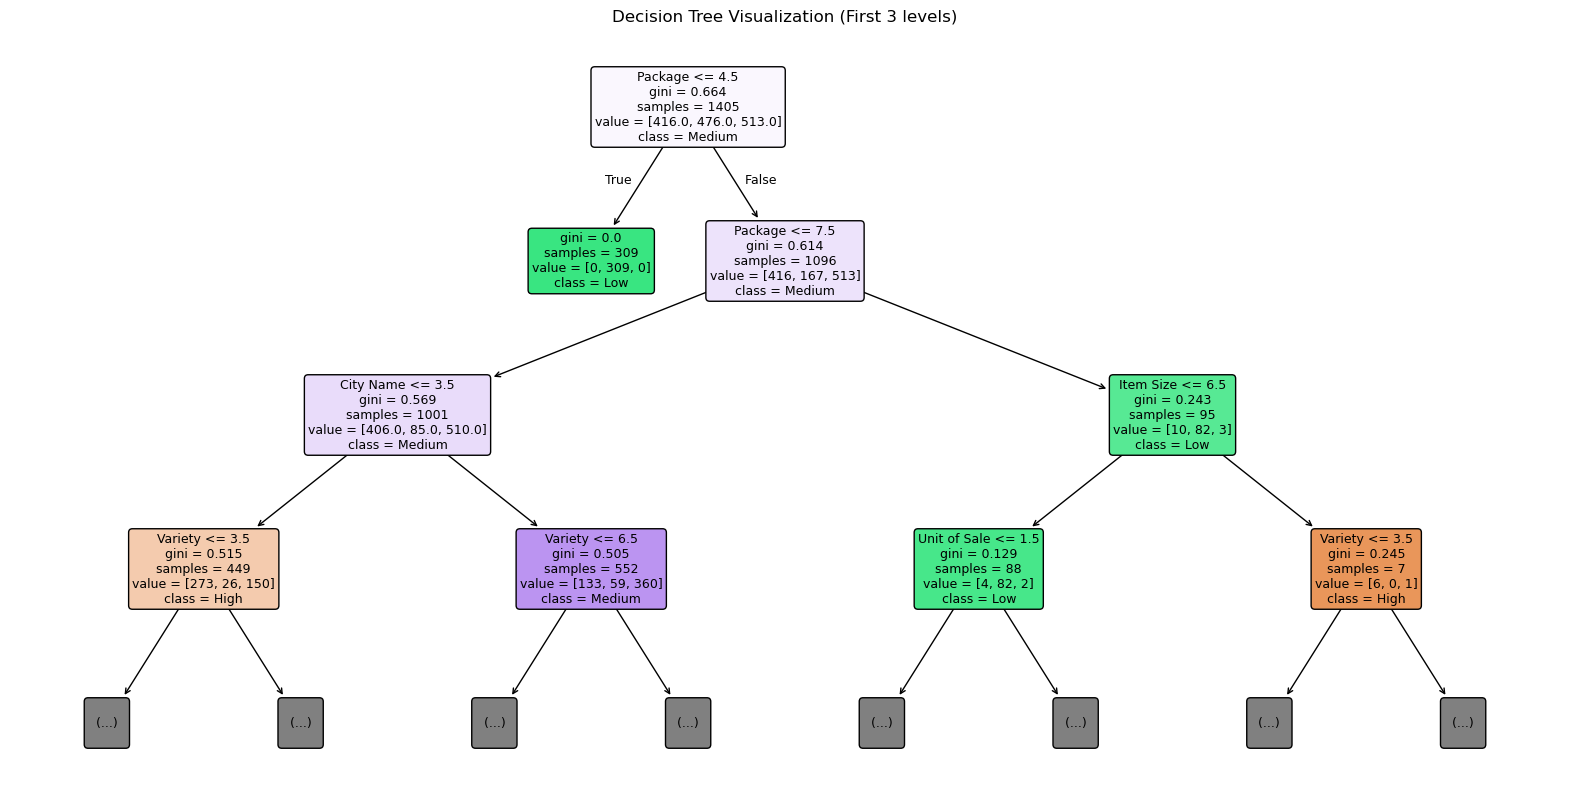

In [383]:
# 2. Decision Tree Visualization: Showing the logic of the first 3 levels
plt.figure(figsize=(20,10))
plot_tree(model, 
          feature_names=X.columns, 
          class_names=['High', 'Low', 'Medium'], 
          filled=True, 
          rounded=True, 
          max_depth=3) 
plt.title("Decision Tree Visualization (First 3 levels)")
plt.show()


In [384]:
# 3. Feature Importance: Analyzing which factors (Variety, City, etc.) affect price most
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

print("--- Top Features Predictive of Price ---")
print(importances)

--- Top Features Predictive of Price ---
            feature  importance
2           Package    0.467401
3           Variety    0.149978
0         City Name    0.108120
8         Item Size    0.070701
6            Origin    0.068639
10     Unit of Sale    0.068247
5              Date    0.030292
7   Origin District    0.018156
9             Color    0.010514
1              Type    0.007590
12      Unnamed: 25    0.000362
4       Sub Variety    0.000000
11           Repack    0.000000


In [ ]:
# 4. Optimization (Pruning): Limiting tree depth to 5 to prevent Overfitting
model_tuned = DecisionTreeClassifier(max_depth=5, random_state=42)
model_tuned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [386]:
# Accuracy check of the new model
y_pred_tuned = model_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Accuracy after tuning (max_depth=5): {accuracy_tuned:.2f}")

Accuracy after tuning (max_depth=5): 0.83


# Questions to Answer in Your Final Report

# 1. What feature(s) did the model find most predictive of the pumpkin's price?

Based on attribute importance analysis and decision tree visualization, the packaging model identified the most predictive attribute, with an importance of approximately 46%. This indicates that the type of packaging (e.g., large boxes versus small cartons) is the strongest factor in determining pumpkin price category. Other influential attributes included variety (approximately 15%) and city name (approximately 11%), demonstrating that variety and market location significantly impact pricing.

# 2. How did the Decision Tree's approach feel different to you compared to what you know about Logistic Regression?

While logistic regression uses a mathematical sigmoid function to calculate probabilities and works best with linear relationships, the decision tree simply segments the data using "if-else" logic. This transparency allowed us to visually trace the decision path (For example,"If package X and type Y, then the price is high"), providing a clear understanding of the model's logic without the need for complex feature measurements.
# 3. Did you notice any signs of overfitting before you tuned the hyperparameters?

Yes, there were clear signs of over-allocation in the prototype. The first trial with the default settings achieved an exceptionally high accuracy of 97%, indicating that the tree had grown excessively and "saved" noise and specific outliers from the training set. This was confirmed when we set the tree depth to max_depth=5; the accuracy dropped to 83%. Despite the lower accuracy, the modified model is more reliable because it captures overall trends rather than storing individual data points, making it more effective at predicting prices based on new, unseen data.